In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Question 1 [2x11]
A new washing machine prototype is developed by a Company. It’s unique design enables efficient removal of dirt but at the same time it is felt that the color of the cloth also gets removed during the washing. Hence the washing machine is subject to some trials wherein the color in the wash liquid (C) is analyzed using a photometer. The variables considered while washing with good quality water are listed as follows.
1) Temperature of the water (X1)
2) Amount of detergent powder (X2)
The washing time is set for a standard 10-minute cycle.
It is assumed that the addition of powder does not induce additional heating or cooling of the water. The data collected are given below. The model to be considered is NOT known. Since the two variables are of different magnitudes it is better to code the variables as shown in Table 1. Consider a linear regression model involving the main effects X1 and X2 only.
NOTE: Give all formulae and matrices. Also provide code.

In [ ]:
Tc = np.array([-1, 0, 1, -1, 0, 1, -1, 0, 1, 0.5, -0.5, 0.5, -0.5]).reshape((-1, 1))
Pc = np.array([-1, -1, -1, 0, 0, 0, 1, 1, 1, -0.5, -0.5, 0.5, 0.5]).reshape((-1, 1))
Y = np.array([234, 257.5, 282, 193.5, 187, 181.5, 153, 116.5, 81, 226.9, 217.9, 141.4, 162.4]).reshape((-1, 1))

In [ ]:
X = np.column_stack((np.ones(len(Tc)), Tc, Pc))
X

array([[ 1. , -1. , -1. ],
       [ 1. ,  0. , -1. ],
       [ 1. ,  1. , -1. ],
       [ 1. , -1. ,  0. ],
       [ 1. ,  0. ,  0. ],
       [ 1. ,  1. ,  0. ],
       [ 1. , -1. ,  1. ],
       [ 1. ,  0. ,  1. ],
       [ 1. ,  1. ,  1. ],
       [ 1. ,  0.5, -0.5],
       [ 1. , -0.5, -0.5],
       [ 1. ,  0.5,  0.5],
       [ 1. , -0.5,  0.5]])

a) Present the (X'X)-1 matrix

In [ ]:
C = np.linalg.inv(X.T@X)
C

array([[0.07692308, 0.        , 0.        ],
       [0.        , 0.14285714, 0.        ],
       [0.        , 0.        , 0.14285714]])

b) The least squares estimates of the parameters including intercept

In [ ]:
beta_hat = C@(X.T@Y)
beta_hat

array([[187.27692308],
       [ -6.        ],
       [-70.5       ]])

c) Compare actual values with model predicted values

In [ ]:
Y_model = X@beta_hat
compare = np.column_stack((Y, Y_model))
compare

array([[234.        , 263.77692308],
       [257.5       , 257.77692308],
       [282.        , 251.77692308],
       [193.5       , 193.27692308],
       [187.        , 187.27692308],
       [181.5       , 181.27692308],
       [153.        , 122.77692308],
       [116.5       , 116.77692308],
       [ 81.        , 110.77692308],
       [226.9       , 219.52692308],
       [217.9       , 225.52692308],
       [141.4       , 149.02692308],
       [162.4       , 155.02692308]])

d) the degrees of freedom for residual sum of squares

In [ ]:
df_T = len(Tc) - 1
df_Rg = len(beta_hat) - 1
df_Rs = df_T - df_Rg
print("Total df : ", df_T)
print("Regression df : ", df_Rg)
print("Residual df : ", df_Rs)

Total df :  12
Regression df :  2
Residual df :  10


e) the estimated standard error of the least square estimators


In [ ]:
SS_error = Y.T@Y - beta_hat.T@X.T@Y
sigma = np.sqrt(SS_error/df_Rs)
var_cov_matrix = C*sigma**2
Std_error = np.sqrt(var_cov_matrix)
print(f"SS_error : {SS_error}")
print(f"sigma : {sigma}")
print(f"Variance Covariance matrix : \n{var_cov_matrix}")
print(f"Std Error of estimates : \n{Std_error}")

SS_error : [[3825.59307692]]
sigma : [[19.55912339]]
Variance Covariance matrix : 
[[29.42763905  0.          0.        ]
 [ 0.         54.65132967  0.        ]
 [ 0.          0.         54.65132967]]
Std Error of estimates : 
[[5.42472479 0.         0.        ]
 [0.         7.39265376 0.        ]
 [0.         0.         7.39265376]]


f) the SSTotal, SSResidual, and SSRegression all corrected for the intercept

In [ ]:
n = df_T + 1
SS_Total = Y.T@Y - (np.sum(Y)**2/n)
SS_Reg = SS_Total - SS_error
SS_Res = sum((Y - Y_model)**2)
print(f"Total sum of squares : {SS_Total}")
print(f"Regression sum of squares : {SS_Reg}")
print(f"Residual sum of squares : {SS_Res}")
print(f"Error sum of squares : {SS_error} (same as residual)")

Total sum of squares : [[38869.34307692]]
Regression sum of squares : [[35043.75]]
Residual sum of squares : [3825.59307692]
Error sum of squares : [[3825.59307692]] (same as residual)


g) R2

In [ ]:
R2 = SS_Reg/SS_Total
print("R2 : ",np.round(R2,4))

R2 :  [[0.9016]]


h) adjusted R2

In [ ]:
Adj_R2 = 1 - ((SS_Res/df_Rs)/(SS_Total/df_T))
print(f"Adjusted R2 : {Adj_R2}")

Adjusted R2 : [[0.88189377]]


i) PRESS

In [ ]:
H = X @ C @ X.T
h = np.diag(H)
e = (Y - Y_model).flatten()
E = (e/(1 - h)).flatten()
PRESS = np.sum(E**2)
print(f"PRESS : {PRESS}")

PRESS : 9173.24870729858


j) R2_PRESS

In [ ]:
R2_PRESS = 1 - (PRESS/SS_Total)
print(f"R2_PRESS : {R2_PRESS}")

R2_PRESS : [[0.76399785]]


# Question 9 [8]
Let us say that you come across the following data set. You want to identify the outliers
in this data set.

180 156 9 176 163 1827 166 171
Identify the outlier(s) using the following means
a) Visual inspection
b) Drawing figures – for e.g. box plot
c) Using interquartile range
d) Assume a normal distribution and find z-scores. An z score >3 or <-3 indicates
the presence of an outlier

In [ ]:
data = np.array([180, 156, 9, 176, 163, 1827, 166, 171])

a) Visual inspection -
9, 1827 both end seem to be as outliers

b) Drawing figures

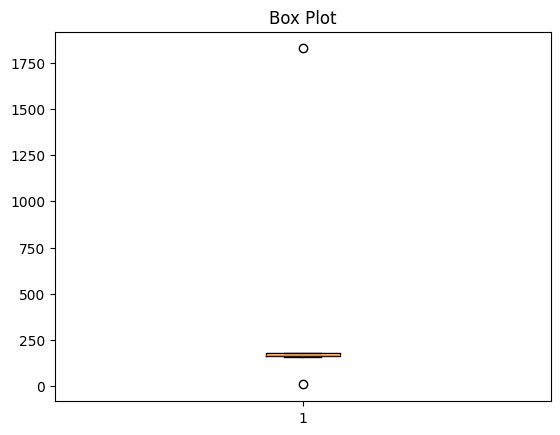

In [ ]:
plt.boxplot(data)
plt.title("Box Plot")
plt.show()

c) Using interquartile range

In [ ]:
Q1 = np.quantile(data, 0.25)
Q2 = np.quantile(data, 0.5)
Q3 = np.quantile(data, 0.75)
IQR = Q3 - Q2
LB = Q1 - 1.5*IQR
UB = Q3 + 1.5*IQR
outliers = data[(data < LB) | (data > UB)]
print(f"Q1 : {Q1}")
print(f"Q2 : {Q2}")
print(f"Q3 : {Q3}")
print(f"IQR : {IQR}")
print(f"Lower Bound : {LB}")
print(f"Upper Bound : {UB}")
print(f"Outliers : {outliers}")

Q1 : 161.25
Q2 : 168.5
Q3 : 177.0
IQR : 8.5
Lower Bound : 148.5
Upper Bound : 189.75
Outliers : [   9 1827]


d) Assume a normal distribution and find z-scores. An z score >3 or <-3 indicates the presence of an outlier

In [ ]:
mean = data.mean()
std = data.std(ddof=1)
z = (data - mean) / std
out = data[(z < -3) | (z > 3)]
z

array([-0.29478746, -0.33498575, -0.58120028, -0.30148718, -0.32326125,
        2.4638202 , -0.31823646, -0.30986182])